# NFL Player Contact Detection: YOLO and Video Feature Probe

This notebook tests whether video-derived signals can improve the current
tracking-first pipeline. It starts with baseline helmet overlays because those
boxes are competition-provided and submission-safe, then optionally runs YOLO in
research mode when internet access is available.

Research mode can install `ultralytics` and download YOLO weights. A final
Kaggle submission notebook cannot rely on internet, so any YOLO dependency that
survives this probe must later be attached as offline Kaggle inputs.

## 1. Setup and Configuration

This is an investigation notebook, not a submission notebook. The first goal is
to understand visibility, box geometry, and detector behavior on a small sample
before committing to an expensive full-video feature pipeline.

Use `YOLO_RESEARCH_MODE = True` for internet-enabled Kaggle exploration. Set it
to `False` when checking whether the notebook can run with only offline inputs.

In [1]:
import importlib.util
import subprocess
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import Image, display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

NOTEBOOK_VERSION = "YOLO_VIDEO_PROBE_V2_DOWNLOAD"
NOTEBOOK_NAME = "YOLO and Video Feature Probe"
TARGET = "contact"
ID_COL = "contact_id"
VIDEO_FPS = 59.94
TRACKING_HZ = 10
SNAP_OFFSET_SECONDS = 5
SNAP_FRAME = int(round(VIDEO_FPS * SNAP_OFFSET_SECONDS))
RANDOM_STATE = 42
SAMPLE_ROWS = 50_000
YOLO_CONFIDENCE = 0.25
YOLO_RESEARCH_MODE = True
ALLOW_YOLO_INSTALL = True
ALLOW_YOLO_DOWNLOAD = True
YOLO_MODEL_NAME = "yolov8n.pt"
YOLO_WEIGHTS_CANDIDATES = [
    Path("/kaggle/input/yolov8-weights/yolov8n.pt"),
    Path("/kaggle/input/ultralytics-yolo-weights/yolov8n.pt"),
    Path("/kaggle/input/yolo-weights/yolov8n.pt"),
]

REQUIRED_DATA_FILES = [
    "train_labels.csv",
    "train_baseline_helmets.csv",
    "train_player_tracking.csv",
    "train_video_metadata.csv",
]
DATA_DIR = Path("/kaggle/input/competitions/nfl-player-contact-detection")
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")

missing_files = [
    filename for filename in REQUIRED_DATA_FILES
    if not (DATA_DIR / filename).exists()
]
if missing_files:
    raise FileNotFoundError(
        f"Missing required files in {DATA_DIR}: {missing_files}"
    )

print(f"NOTEBOOK_VERSION: {NOTEBOOK_VERSION}")
print(f"NOTEBOOK_NAME: {NOTEBOOK_NAME}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR.resolve()}")
print(f"YOLO_RESEARCH_MODE: {YOLO_RESEARCH_MODE}")

NOTEBOOK_VERSION: YOLO_VIDEO_PROBE_V2_DOWNLOAD
NOTEBOOK_NAME: YOLO and Video Feature Probe
DATA_DIR: /kaggle/input/competitions/nfl-player-contact-detection
OUTPUT_DIR: /kaggle/working
YOLO_RESEARCH_MODE: True


## 2. Helper Functions

The helpers keep the probe reproducible: parse contact IDs, map 10 Hz label
steps to 59.94 Hz video frames, read one frame, draw helmet/YOLO overlays, and
optionally prepare YOLO in research mode.

In [2]:
def parse_contact_id(df: pd.DataFrame) -> pd.DataFrame:
    """Split Kaggle contact_id into play, step, player1, and player2 fields."""
    out = df.copy()
    parts = out[ID_COL].astype(str).str.split("_", expand=True)
    out["game_play"] = parts[0] + "_" + parts[1]
    out["step"] = parts[2].astype("int16")
    out["nfl_player_id_1"] = parts[3].astype(str)
    out["nfl_player_id_2"] = parts[4].astype(str)
    out["contact_type"] = np.where(
        out["nfl_player_id_2"].eq("G"), "ground", "player_player"
    )
    return out


def step_to_video_frame(step: int) -> int:
    """Map a 10 Hz label step to the synchronized video frame index."""
    return int(round(SNAP_FRAME + step * (VIDEO_FPS / TRACKING_HZ)))


def read_video_frame(video_path: Path, frame_number: int):
    """Read one frame from an mp4 file with OpenCV when available."""
    try:
        import cv2
    except ImportError:
        print("OpenCV is not available in this environment.")
        return None

    if not video_path.exists():
        print(f"Missing video file: {video_path}")
        return None

    capture = cv2.VideoCapture(str(video_path))
    capture.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ok, frame = capture.read()
    capture.release()
    if not ok:
        print(f"Could not read frame {frame_number} from {video_path.name}")
        return None
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


def draw_boxes(
    frame,
    boxes: pd.DataFrame,
    target_players: set[str] | None = None,
    title: str | None = None,
):
    """Draw helmet boxes and highlight contact-candidate players."""
    if frame is None:
        return None
    target_players = target_players or set()
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.imshow(frame)
    ax.axis("off")
    if title:
        ax.set_title(title)
    for row in boxes.itertuples(index=False):
        player_id = str(row.nfl_player_id)
        is_target = player_id in target_players
        rect = patches.Rectangle(
            (row.left, row.top),
            row.width,
            row.height,
            linewidth=2.6 if is_target else 0.8,
            edgecolor="red" if is_target else "yellow",
            facecolor="none",
            alpha=0.9,
        )
        ax.add_patch(rect)
        if is_target:
            ax.text(
                row.left,
                max(row.top - 4, 0),
                player_id,
                color="white",
                fontsize=8,
                bbox={"facecolor": "red", "alpha": 0.8, "pad": 1},
            )
    return fig


def find_yolo_weights() -> Path | None:
    """Return the first attached offline YOLO weight file, if any."""
    for path in YOLO_WEIGHTS_CANDIDATES:
        if path.exists():
            return path
    return None


def ensure_ultralytics() -> bool:
    """Install ultralytics only in explicit research mode."""
    if importlib.util.find_spec("ultralytics") is not None:
        print("ultralytics is already installed.")
        return True
    if not (YOLO_RESEARCH_MODE and ALLOW_YOLO_INSTALL):
        print("ultralytics is unavailable and install is disabled.")
        return False
    print("Installing ultralytics for research-mode YOLO probing...")
    try:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "ultralytics",
        ])
    except Exception as exc:
        print(f"Could not install ultralytics: {exc}")
        return False
    return importlib.util.find_spec("ultralytics") is not None


def load_yolo_model():
    """Load attached YOLO weights or download a small model in research mode."""
    if not ensure_ultralytics():
        return None

    from ultralytics import YOLO

    weights = find_yolo_weights()
    if weights is not None:
        print(f"Loading attached YOLO weights: {weights}")
        return YOLO(str(weights))

    if not (YOLO_RESEARCH_MODE and ALLOW_YOLO_DOWNLOAD):
        print("No attached YOLO weights found and download is disabled.")
        print("Checked:")
        for candidate in YOLO_WEIGHTS_CANDIDATES:
            print(f"- {candidate}")
        return None

    print(f"Downloading/loading YOLO model for research: {YOLO_MODEL_NAME}")
    try:
        return YOLO(YOLO_MODEL_NAME)
    except Exception as exc:
        print(f"Could not download/load YOLO model: {exc}")
        return None

## 3. Load Data and Pick Contact Examples

We inspect one positive player-player contact and one positive ground contact.
This keeps the notebook fast while still covering the two target families.

In [3]:
labels = pd.read_csv(DATA_DIR / "train_labels.csv")
labels = parse_contact_id(labels)
helmets = pd.read_csv(DATA_DIR / "train_baseline_helmets.csv")
tracking = pd.read_csv(DATA_DIR / "train_player_tracking.csv")
metadata = pd.read_csv(DATA_DIR / "train_video_metadata.csv")

positive_examples = (
    labels.loc[labels[TARGET].eq(1)]
    .groupby("contact_type", group_keys=False)
    .head(1)
    .copy()
)
positive_examples["video_frame"] = positive_examples["step"].map(step_to_video_frame)
display(positive_examples[[
    ID_COL, "game_play", "step", "video_frame", "contact_type",
    "nfl_player_id_1", "nfl_player_id_2", TARGET,
]])

print(f"labels: {labels.shape}")
print(f"helmets: {helmets.shape}")
print(f"tracking: {tracking.shape}")
print(f"metadata: {metadata.shape}")

,contact_id,game_play,step,video_frame,contact_type,nfl_player_id_1,nfl_player_id_2,contact
809,58168_003392_3_41944_42565,58168_003392,3,318,player_player,41944,42565,1
2772,58168_003392_10_38567_G,58168_003392,10,360,ground,38567,G,1


labels: (4721618, 8)
helmets: (3783616, 12)
tracking: (1353053, 17)
metadata: (480, 7)


## 4. Helmet Overlay Demo

The baseline helmet files already provide player assignments. Before adding
YOLO, we should understand whether the candidate players are visible and
whether the provided boxes line up with the contact frame.

video: 58168_003392_Sideline.mp4
frame: 318
boxes on frame: 22


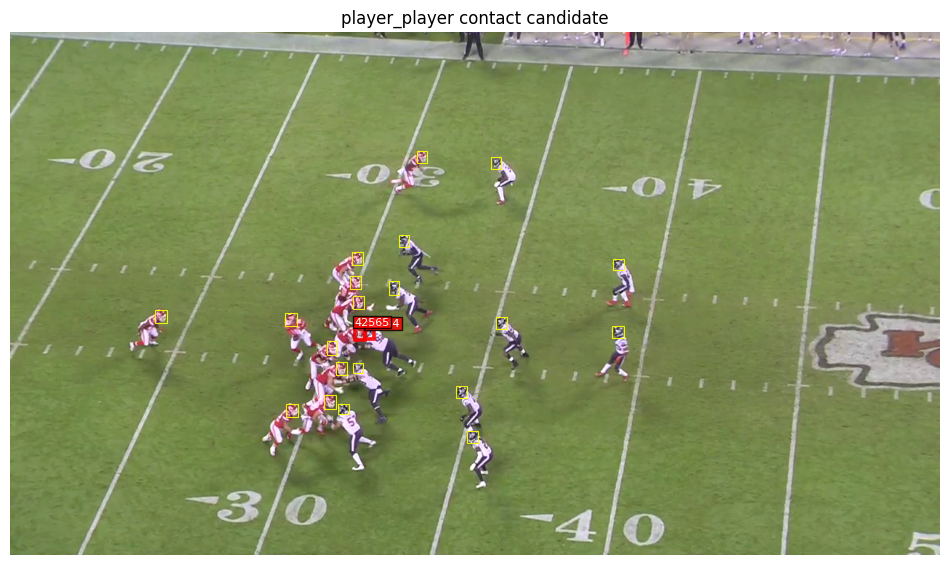

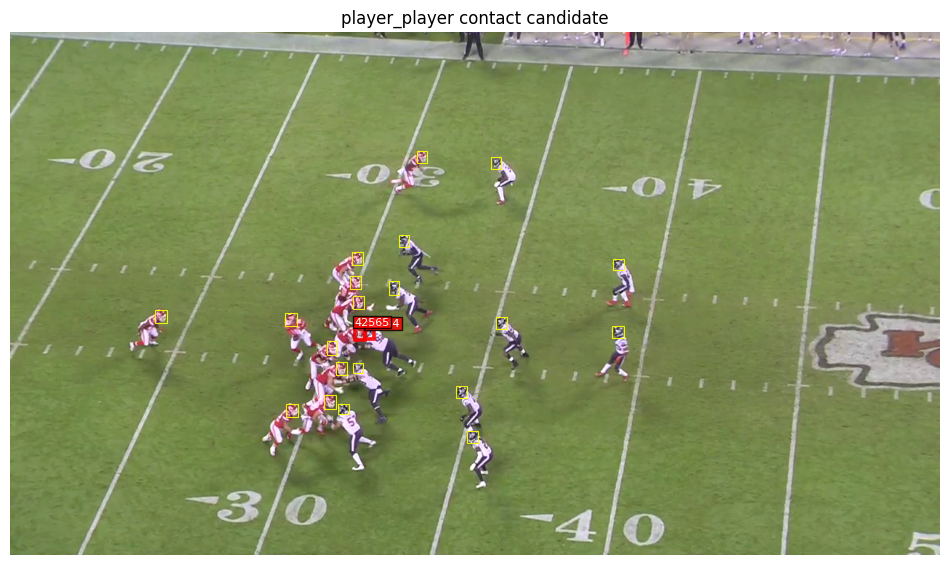

In [4]:
demo_row = positive_examples.iloc[0]
demo_view = "Sideline"
demo_frame = int(demo_row["video_frame"])
demo_video = helmets.loc[
    helmets["game_play"].eq(demo_row["game_play"])
    & helmets["view"].eq(demo_view),
    "video",
].iloc[0]
demo_boxes = helmets.loc[
    helmets["video"].eq(demo_video)
    & helmets["frame"].eq(demo_frame)
].copy()
target_players = {str(demo_row["nfl_player_id_1"])}
if demo_row["nfl_player_id_2"] != "G":
    target_players.add(str(demo_row["nfl_player_id_2"]))

print(f"video: {demo_video}")
print(f"frame: {demo_frame}")
print(f"boxes on frame: {len(demo_boxes)}")
frame = read_video_frame(DATA_DIR / "train" / demo_video, demo_frame)
fig = draw_boxes(
    frame,
    demo_boxes,
    target_players,
    title=f"{demo_row['contact_type']} contact candidate",
)
if fig is not None:
    output_path = OUTPUT_DIR / "yolo_probe_helmet_overlay.png"
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()
    display(Image(filename=str(output_path)))

## 5. Optional YOLO Frame Probe

YOLO is useful only if it adds information beyond the provided helmet boxes.
In research mode, this cell can install `ultralytics` and download `yolov8n.pt`
when internet is enabled. For submission-style offline checks, set
`YOLO_RESEARCH_MODE = False` and attach weights through Kaggle inputs.

In [5]:
yolo_model = load_yolo_model()

if yolo_model is None:
    print("Skipping YOLO inference: no model is available.")
elif frame is None:
    print("Skipping YOLO inference: no readable demo frame.")
else:
    result = yolo_model.predict(
        frame,
        conf=YOLO_CONFIDENCE,
        verbose=False,
    )[0]
    detections = []
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy.cpu().numpy()[0]
        cls_id = int(box.cls.cpu().numpy()[0])
        confidence = float(box.conf.cpu().numpy()[0])
        class_name = result.names.get(cls_id, str(cls_id))
        detections.append({
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "class_id": cls_id,
            "class_name": class_name,
            "confidence": confidence,
            "width": x2 - x1,
            "height": y2 - y1,
            "area": (x2 - x1) * (y2 - y1),
        })
    detections = pd.DataFrame(detections)
    print(f"detections: {len(detections)}")
    display(detections.head(30))

    if len(detections):
        fig, ax = plt.subplots(figsize=(12, 7))
        ax.imshow(frame)
        ax.axis("off")
        ax.set_title("YOLO detections on contact frame")
        for row in detections.itertuples(index=False):
            rect = patches.Rectangle(
                (row.x1, row.y1),
                row.width,
                row.height,
                linewidth=1.6,
                edgecolor="lime",
                facecolor="none",
                alpha=0.9,
            )
            ax.add_patch(rect)
            ax.text(
                row.x1,
                max(row.y1 - 4, 0),
                f"{row.class_name} {row.confidence:.2f}",
                color="black",
                fontsize=8,
                bbox={"facecolor": "lime", "alpha": 0.75, "pad": 1},
            )
        output_path = OUTPUT_DIR / "yolo_probe_detections.png"
        fig.savefig(output_path, bbox_inches="tight")
        plt.show()
        display(Image(filename=str(output_path)))

Installing ultralytics for research-mode YOLO probing...


Could not install ultralytics: Command '['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'ultralytics']' returned non-zero exit status 1.
Skipping YOLO inference: no model is available.


ERROR: Could not find a version that satisfies the requirement ultralytics (from versions: none)
ERROR: No matching distribution found for ultralytics


## 6. Helmet-Derived Feature Probe

These compact features are cheap enough to consider for the tracking model:
player box visibility, box area, and player-pair pixel distance in each view.
They are not YOLO-dependent, so they can be used even if external detector
weights are unavailable.

In [6]:
feature_sample = labels.sample(
    min(SAMPLE_ROWS, len(labels)),
    random_state=RANDOM_STATE,
).copy()
positives = labels.loc[labels[TARGET].eq(1)].sample(
    min(10_000, int(labels[TARGET].sum())),
    random_state=RANDOM_STATE,
)
feature_sample = pd.concat([feature_sample, positives], ignore_index=True)
feature_sample = feature_sample.drop_duplicates(ID_COL)
feature_sample["frame"] = feature_sample["step"].map(step_to_video_frame)
feature_sample["p1_id"] = feature_sample["nfl_player_id_1"].astype("int64")
feature_sample["p2_id"] = pd.to_numeric(
    feature_sample["nfl_player_id_2"], errors="coerce"
)

view = "Sideline"
view_helmets = helmets.loc[helmets["view"].eq(view)].copy()
box_cols = ["game_play", "frame", "nfl_player_id", "left", "width", "top", "height"]
p1_boxes = view_helmets[box_cols].rename(columns={
    "nfl_player_id": "p1_id",
    "left": "p1_left",
    "width": "p1_width",
    "top": "p1_top",
    "height": "p1_height",
})
p2_boxes = view_helmets[box_cols].rename(columns={
    "nfl_player_id": "p2_id",
    "left": "p2_left",
    "width": "p2_width",
    "top": "p2_top",
    "height": "p2_height",
})
features = feature_sample.merge(
    p1_boxes,
    on=["game_play", "frame", "p1_id"],
    how="left",
).merge(
    p2_boxes,
    on=["game_play", "frame", "p2_id"],
    how="left",
)
features["p1_box_area"] = features["p1_width"] * features["p1_height"]
features["p2_box_area"] = features["p2_width"] * features["p2_height"]
features["p1_visible"] = features["p1_box_area"].notna().astype("int8")
features["p2_visible"] = features["p2_box_area"].notna().astype("int8")
features["both_players_visible"] = (
    features["p1_visible"].eq(1) & features["p2_visible"].eq(1)
).astype("int8")
features["p1_center_x"] = features["p1_left"] + features["p1_width"] / 2
features["p1_center_y"] = features["p1_top"] + features["p1_height"] / 2
features["p2_center_x"] = features["p2_left"] + features["p2_width"] / 2
features["p2_center_y"] = features["p2_top"] + features["p2_height"] / 2
features["helmet_pair_distance_px"] = np.sqrt(
    (features["p1_center_x"] - features["p2_center_x"]) ** 2
    + (features["p1_center_y"] - features["p2_center_y"]) ** 2
)

summary_cols = [
    "p1_visible",
    "p2_visible",
    "both_players_visible",
    "p1_box_area",
    "p2_box_area",
    "helmet_pair_distance_px",
]
display(features.groupby(["contact_type", TARGET], observed=True)[summary_cols].mean())
display(features[summary_cols + ["contact_type", TARGET]].describe(include="all"))

p1_visible  p2_visible  both_players_visible  \
contact_type  contact                                                 
ground        0          0.816467    0.000000              0.000000   
              1          0.743876    0.000000              0.000000   
player_player 0          0.810430    0.819185              0.730225   
              1          0.919641    0.923877              0.864955   

                       p1_box_area  p2_box_area  helmet_pair_distance_px  
contact_type  contact                                                     
ground        0         234.582833          NaN                      NaN  
              1         430.673123          NaN                      NaN  
player_player 0         242.240077   247.789799               286.508127  
              1         207.449470   208.341948                25.479527

,p1_visible,p2_visible,both_players_visible,p1_box_area,p2_box_area,helmet_pair_distance_px,contact_type,contact
count,59881.000000,59881.000000,59881.000000,49220.000000,44252.000000,39769.000000,59881,59881.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,player_player,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,53024,NaN
mean,0.821964,0.738999,0.664134,244.563531,241.374130,242.282456,NaN,0.176450
std,0.382547,0.439184,0.472296,304.390699,302.216512,207.997636,NaN,0.381206
min,0.000000,0.000000,0.000000,18.000000,18.000000,0.500000,NaN,0.000000
25%,1.000000,0.000000,0.000000,99.000000,99.000000,68.807703,NaN,0.000000
50%,1.000000,1.000000,1.000000,154.000000,154.000000,192.850331,NaN,0.000000
75%,1.000000,1.000000,1.000000,255.000000,255.000000,362.503103,NaN,0.000000


## 7. Decision Notes

If helmet visibility and pixel-distance features separate contact from
non-contact rows, the next production experiment should add them to the
tracking model before attempting a full CNN. If YOLO detections are noisy or
redundant with helmet boxes, the safer path is to use the provided helmet boxes
and reserve YOLO/CNN work for crop generation and qualitative review.